## 1.
Используемые функции:

*Biggs Exp02 Function:*
$$ f(x) = \sum_{i=1}^{10} \left( e^{-t_i x_1} - 5 e^{-t_i x_2} - \left(e^{-t_i} - 5 e^{-10 t_i}\right) \right)^2 $$
*Egg Crate Function:*
$$ f(x,y)=x^2 + y^2 + 25(sin^2(x) + sin^2(y)) $$
*Bird Function:*
$$ f(x, y) = sin(x)e^{(1-cos(y))^2}+cos(y)e^{(1-sin(x))^2}+(x-y)^2 $$

Дилемма птицы и яйца решена, сначала было яйцо.

In [33]:
from benchmarkfcns import biggsexp02, eggcrate, bird
from scipy.optimize import minimize
import numpy as np

class Tester:
    def __init__(self, bench, points, minima, bounds):
        self.bench_name = bench.__name__
        self.bench_unwrapped = bench
        self.bench = lambda x: Tester.wrapper(bench, x)
        self.points = points
        self.minima = minima
        self.trajectory = {
            "nelder-mead": {},
            "cg": {},
            "bfgs": {},
        }
        self.bounds = bounds

    def wrapper(fun, point):
        """
        Simple wrapper to handle the disrepancy in benchmarkfcns and minimize's input requirements:
        benchmarkfcns requires its input to be in a [[x, y]] format, while minimize requires [x, y].
        """
        return fun([point])

    def callback(self, x, method, point):
        """To keep track of the iteration trajectory."""
        self.trajectory[method][point].append(x.copy())
    
    def run(self, options=None):
        """Try to find minimum with every method at all specified points."""

        if options == None:
            options = {
                "nelder-mead": {'xatol': 1e-4, 'fatol': 1e-4, 'maxiter': 400},
                "cg": {'gtol': 1e-5, 'eps': 1e-6},
                "bfgs": {'gtol': 1e-5, 'eps': 1e-6},
            }

        results = { "nelder-mead": {}, "cg": {}, "bfgs": {}, }
        trajectory = { "nelder-mead": {}, "cg": {}, "bfgs": {}, }
        for point in self.points:
            point = tuple(point)
            for method in results.keys():
                self.trajectory[method][point] = []
                results[method][point] = minimize(self.bench, point, method=method, options=options[method], callback=lambda x: self.callback(x, method, point))

        self.results = results


testers = [
    Tester(
        biggsexp02,
        [[2, 9], [20, 20], [0, 0]],
        [[1, 10]],
        [[-1, -1], [22, 22]],
    ),
    Tester(
        eggcrate,
        [[3, 1], [-5, -3], [-0.5, 0.2]],
        [[0, 0]],
        [[-6, -6], [6, 6]],
    ),
    Tester(
        bird,
        [[5, 3.5], [-1.6, -3], [0, 0], [-2*np.pi, 2*np.pi]],
        [[4.70104, 3.15294], [-1.58214, -3.13024]],
        [[-2*np.pi - 1, -2*np.pi - 1], [2*np.pi + 1, 2*np.pi + 1]],
    ),
]

## 2.

Получим результаты выполнения и упакуем всё в `.csv`. А ещё нарисуем графики.

In [34]:
from benchmarkfcns.plotting import meshgrid

def display_plot(tester, index, filename="plot"):
    bounds = tester.bounds
    x = np.linspace(bounds[0][0], bounds[1][0], 1000)
    y = np.linspace(bounds[0][1], bounds[1][1], 1000)
    X, Y, Z = meshgrid(x, y, tester.bench_unwrapped)

    colors = {"nelder-mead": "green", "cg": "purple", "bfgs": "blue"}
    method_index = 0
    for k, v in tester.trajectory.items():
        plt.figure(index*3 + method_index)
        plt.title(f"Функция: {tester.bench_name}, метод: {k}")
        plt.xlim(bounds[0][0], bounds[1][0])
        plt.ylim(bounds[0][1], bounds[1][1])
        plt.contour(X, Y, Z, zdir='z', offset=0, cmap='coolwarm')
        for point in tester.points:
            point = tuple(point)
            label = f"({point[0]:.2f}, {point[1]:.2f})"
            plt.plot(*np.transpose([point] + v[point]), label=label, linewidth=2)
        method_index += 1
        plt.plot(*np.transpose(np.array(tester.minima)), "rx", markersize=14, label="minimum")
        plt.legend()
        plt.savefig(f"{filename}{index*3 + method_index}.png")


/tmp/ipykernel_6476/532804610.py:16: UserWarning: The following kwargs were not used by contour: 'zdir', 'offset'
  plt.contour(X, Y, Z, zdir='z', offset=0, cmap='coolwarm')
/tmp/ipykernel_6476/532804610.py:16: UserWarning: The following kwargs were not used by contour: 'zdir', 'offset'
  plt.contour(X, Y, Z, zdir='z', offset=0, cmap='coolwarm')


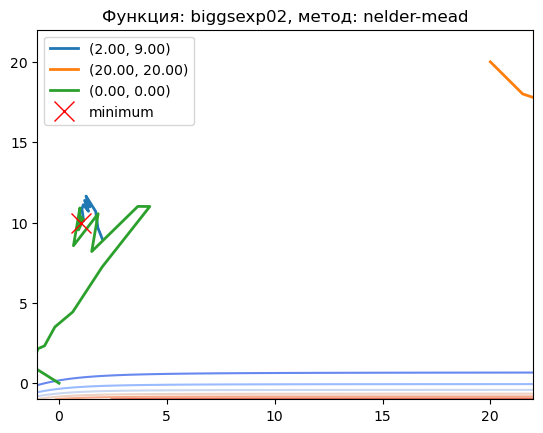

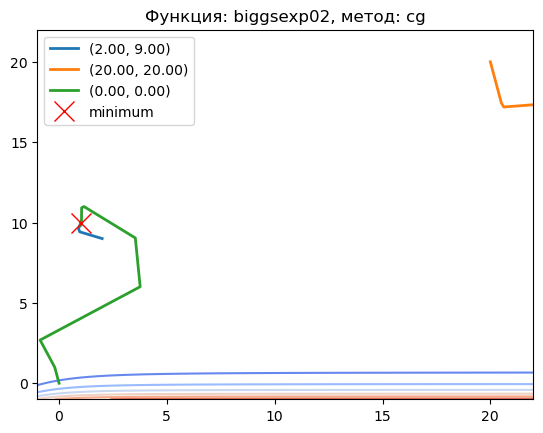

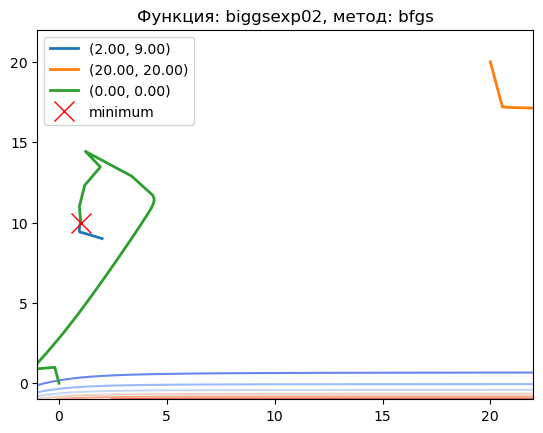

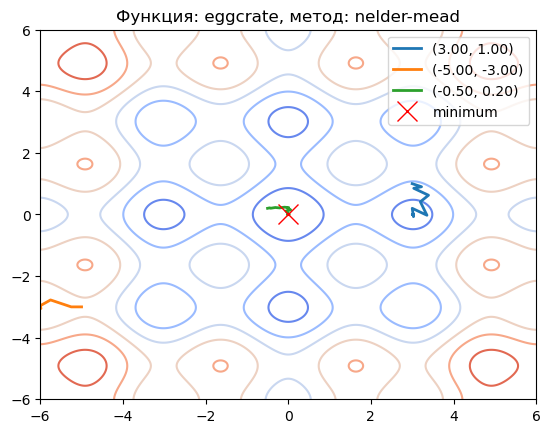

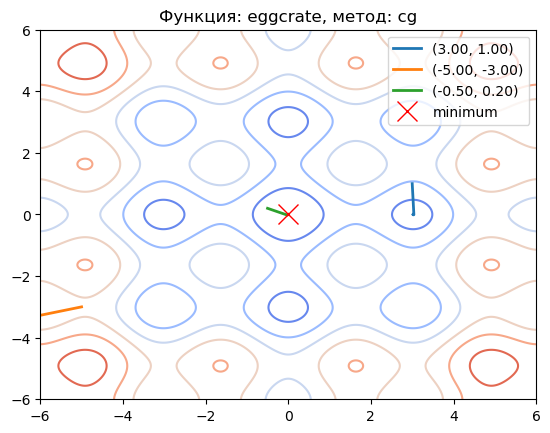

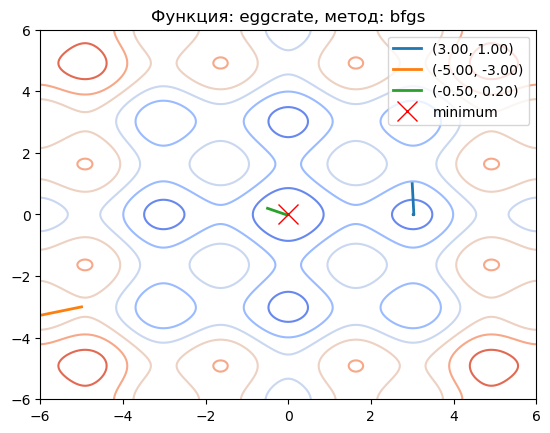

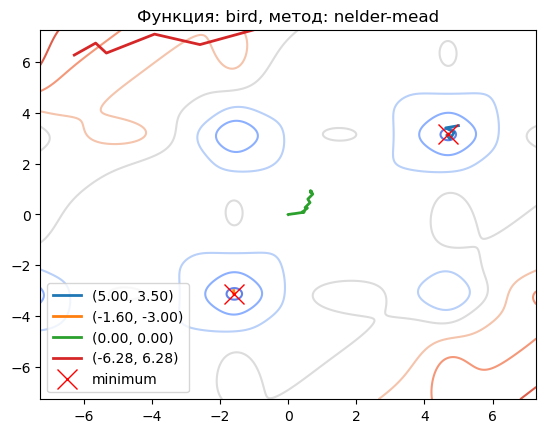

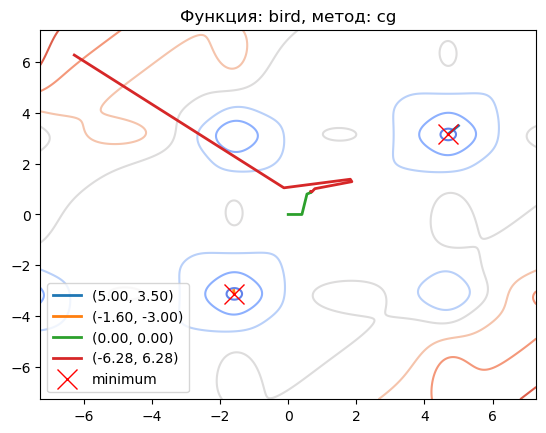

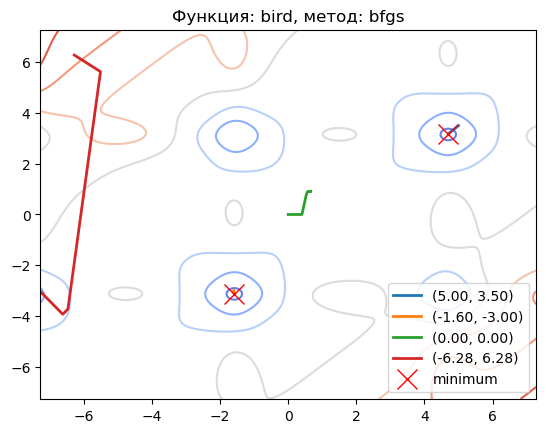

In [35]:
import csv
import matplotlib.pyplot as plt

for i in range(len(testers)):
    tester = testers[i]
    tester.run()
    display_plot(tester, i)
    with open(f"{tester.bench_name}.csv", "w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["$x_0$"] + ["iters", "$f$", "err"] + ["iters", "$f$", "$nabla f$", "err"] * 2)
        for point in tester.points:
            point = tuple(point)
            row = [point]
            for k, v in tester.results.items():
                res_obj = v[point]
                errors = [np.linalg.norm(res_obj.get("x") - np.array(x)) for x in tester.minima]
                if k == "nelder-mead":
                    row += [
                        res_obj.get("nit"),
                        res_obj.get("nfev"),
                        min(errors)
                    ]
                else:
                    row += [
                        res_obj.get("nit"),
                        res_obj.get("nfev"),
                        res_obj.get("njev"),
                        min(errors)
                    ]
            writer.writerow(row)

Отдельно поварьируем гиперпараметры.
Выберем одну функцию для рассмотрения: Biggs EXP02

/tmp/ipykernel_6476/532804610.py:16: UserWarning: The following kwargs were not used by contour: 'zdir', 'offset'
  plt.contour(X, Y, Z, zdir='z', offset=0, cmap='coolwarm')


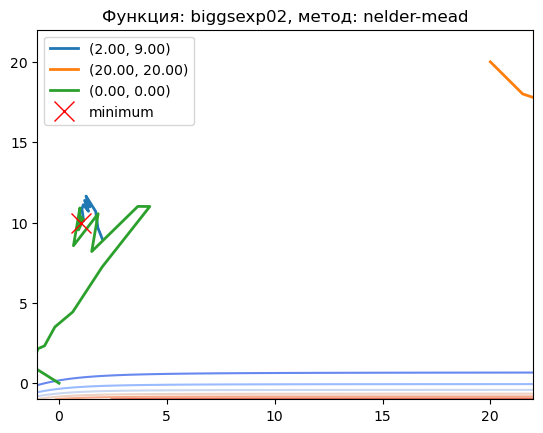

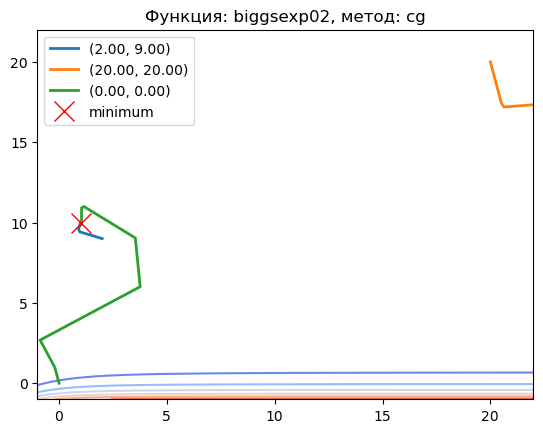

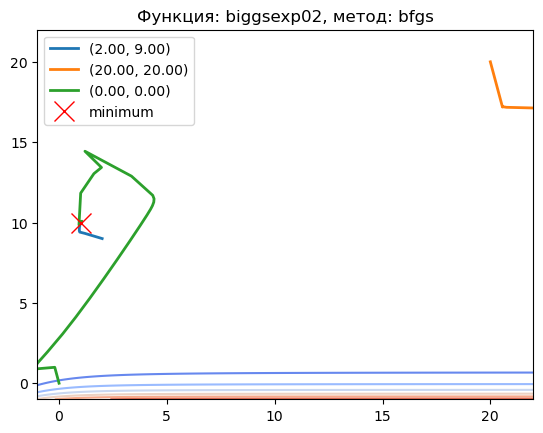

In [36]:
tester = testers[0]

tester.run(options={
    "nelder-mead": {'xatol': 1e-3, 'fatol': 1e-3, 'maxiter': 80},
    "cg": {'gtol': 1e-4, 'eps': 1e-4},
    "bfgs": {'gtol': 1e-4, 'eps': 1e-4},
})

display_plot(tester, 0, "perturbed-plot")

with open("biggsexp02-hyper-perturbed.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["$x_0$"] + ["iters", "$f$", "err"] + ["iters", "$f$", "$nabla f$", "err"] * 2)
    for point in tester.points:
        point = tuple(point)
        row = [point]
        for k, v in tester.results.items():
            res_obj = v[point]
            errors = [np.linalg.norm(res_obj.get("x") - np.array(x)) for x in tester.minima]
            if k == "nelder-mead":
                row += [
                    res_obj.get("nit"),
                    res_obj.get("nfev"),
                    min(errors)
                ]
            else:
                row += [
                    res_obj.get("nit"),
                    res_obj.get("nfev"),
                    res_obj.get("njev"),
                    min(errors)
                ]
        writer.writerow(row)

## 3.

Анализ в отдельном `.pdf` файле.